# Multimodal Middle Fusion MLP 768 text basic
- Early Stopping 제거
- BERT 방식의 train/test → train/val 2단계 분할 적용 (stratify, random_state=42)

In [18]:
import os
import pickle
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


## 1. 데이터 로드

In [19]:
video_path = r"C:\Users\User\Desktop\deeplearning\fusion\video_features_768.pkl"
audio_path = r"C:\Users\User\Desktop\deeplearning\fusion\audio_feat_hubert_origin.pkl"
text_path  = r"C:\Users\User\Desktop\deeplearning\fusion\text_features_768(basic+earlystop).pkl"

with open(video_path, "rb") as f:
    video_data = pickle.load(f)
X_video        = video_data["features"]
X_video_labels = video_data["labels"]

with open(audio_path, "rb") as f:
    audio_data = pickle.load(f)
X_audio        = audio_data["audio_feat"]
X_audio_labels = audio_data["labels"]

text_data      = torch.load(text_path, map_location=device)
X_text         = text_data["features"]
X_text_labels  = text_data["labels"]

X_video_labels = torch.as_tensor(X_video_labels).long()
X_audio_labels = torch.as_tensor(X_audio_labels).long()
X_text_labels  = torch.as_tensor(X_text_labels).long()

print(f"X_video       : {X_video.shape}")
print(f"X_video_labels: (긍정 {X_video_labels.sum()} / 부정 {(X_video_labels==0).sum()})")
print(f"X_audio       : {X_audio.shape}")
print(f"X_audio_labels: (긍정 {X_audio_labels.sum()} / 부정 {(X_audio_labels==0).sum()})")
print(f"X_text        : {X_text.shape}")
print(f"X_text_labels : (긍정 {X_text_labels.sum()} / 부정 {(X_text_labels==0).sum()})")

X_video       : torch.Size([2199, 768])
X_video_labels: (긍정 1080 / 부정 1119)
X_audio       : torch.Size([2199, 256])
X_audio_labels: (긍정 1080 / 부정 1119)
X_text        : torch.Size([2199, 768])
X_text_labels : (긍정 1080 / 부정 1119)


In [20]:
# 라벨 일치 확인
X_video_labels_cpu = X_video_labels.cpu()
X_audio_labels_cpu = X_audio_labels.cpu()
X_text_labels_cpu  = X_text_labels.cpu()

print("audio == text :", torch.equal(X_audio_labels_cpu, X_text_labels_cpu))
print("video == text :", torch.equal(X_video_labels_cpu, X_text_labels_cpu))
print("video == audio:", torch.equal(X_video_labels_cpu, X_audio_labels_cpu))

audio == text : True
video == text : False
video == audio: False


## 2. Feature Concatenation

In [21]:
X_video = X_video.to(device)
X_audio = X_audio.to(device)
X_text  = X_text.to(device)

# 세 모달리티 concat → (N, 768*3 = 2304)
fused     = torch.cat([X_video, X_audio, X_text], dim=1)
input_dim = fused.shape[1]

y = torch.as_tensor(X_text_labels).long().to(device)

print(f"fused shape : {fused.shape}")   # (N, 2304)
print(f"y shape     : {y.shape}")
print(f"fused device: {fused.device}")

fused shape : torch.Size([2199, 1792])
y shape     : torch.Size([2199])
fused device: cuda:0


## 3. Train / Val / Test 분할
BERT 파일과 동일하게 `train_test_split` 2단계 방식 사용
- Step 1: 전체 → Train(80%) / Test(20%)
- Step 2: Train → Train(~72%) / Val(~8%)

In [22]:
# CPU numpy 변환 후 sklearn split 사용 (stratify 지원)
fused_np = fused.cpu().numpy()
y_np     = y.cpu().numpy()

# Step 1: Train+Val / Test 분할 (test_size=0.2)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    fused_np, y_np,
    test_size=0.2,
    random_state=42,
    stratify=y_np
)

# Step 2: Train / Val 분할 (val_size=0.1 of original → ~12.5% of trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2,
    random_state=42,
    stratify=y_trainval
)

# Tensor로 변환
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val   = torch.tensor(X_val,   dtype=torch.float32).to(device)
X_test  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_val   = torch.tensor(y_val,   dtype=torch.long).to(device)
y_test  = torch.tensor(y_test,  dtype=torch.long).to(device)

print(f"Train : {X_train.shape[0]}")
print(f"Val   : {X_val.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

Train : 1407
Val   : 352
Test  : 440


## 4. DataLoader

In [23]:
batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)

## 5. 모델 정의

In [24]:
MLP = nn.Sequential(
    nn.Linear(input_dim, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(MLP.parameters(), lr=1e-3)

print(MLP)

Sequential(
  (0): Linear(in_features=1792, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=256, out_features=2, bias=True)
)


## 6. 평가 함수

In [25]:
def evaluate(model, data_loader):
    model.eval()
    all_preds  = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            total_loss += loss.item()

            _, preds = torch.max(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, acc, prec, rec, f1

===== Epoch 0, 학습 전 초기 성능 =====
Train Loss: 0.7777, Acc: 0.1350, F1: 0.1344
Val Loss  : 0.7678, Acc: 0.1534, F1: 0.1507
Test Loss : 0.7605, Acc: 0.1955, F1: 0.1931
Epoch [1/20] Train Loss: 0.1624, Train Acc: 0.9495, Train F1: 0.9495 | Val Loss: 0.3123, Val Acc: 0.8892, Val F1: 0.8892 | Test Loss: 0.3466, Test Acc: 0.8750, Test F1: 0.8750
Epoch [2/20] Train Loss: 0.1535, Train Acc: 0.9517, Train F1: 0.9517 | Val Loss: 0.3010, Val Acc: 0.8864, Val F1: 0.8864 | Test Loss: 0.3275, Test Acc: 0.8750, Test F1: 0.8750
Epoch [3/20] Train Loss: 0.1438, Train Acc: 0.9552, Train F1: 0.9552 | Val Loss: 0.2943, Val Acc: 0.8864, Val F1: 0.8864 | Test Loss: 0.3219, Test Acc: 0.8773, Test F1: 0.8773
Epoch [4/20] Train Loss: 0.1349, Train Acc: 0.9531, Train F1: 0.9531 | Val Loss: 0.2911, Val Acc: 0.8807, Val F1: 0.8807 | Test Loss: 0.3123, Test Acc: 0.8795, Test F1: 0.8795
Epoch [5/20] Train Loss: 0.1315, Train Acc: 0.9545, Train F1: 0.9545 | Val Loss: 0.3020, Val Acc: 0.8864, Val F1: 0.8864 | Test Loss

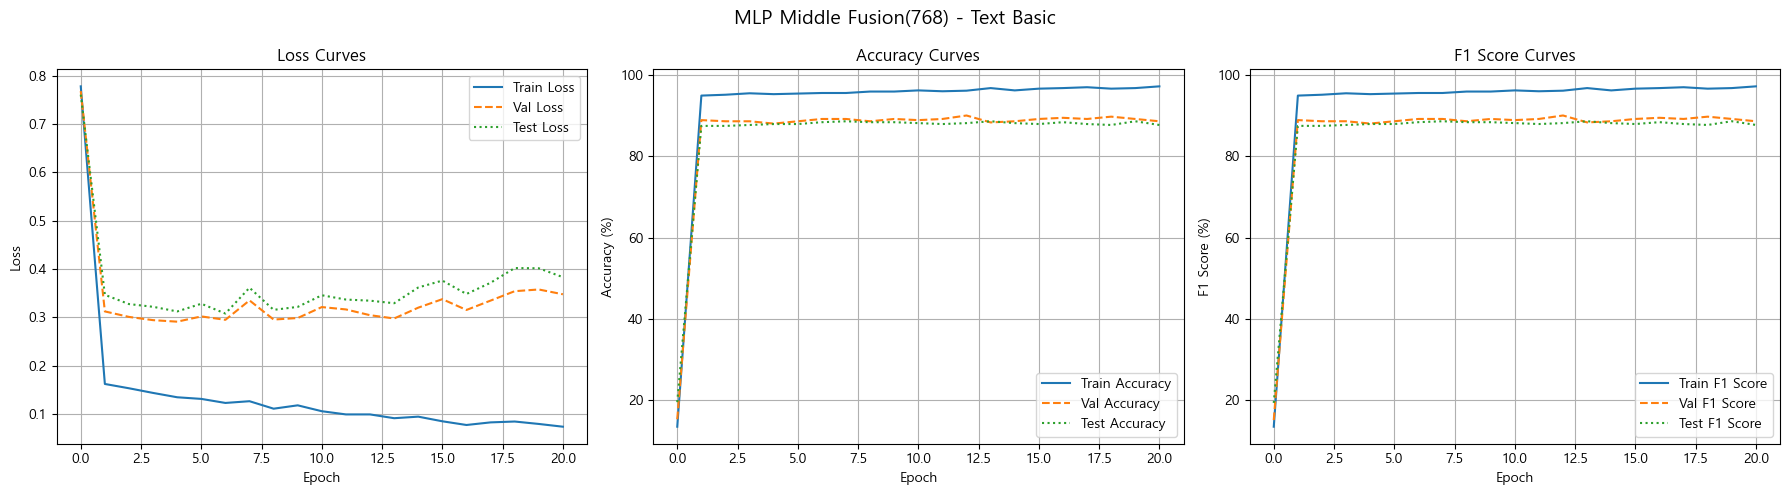

In [26]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

MLP = nn.Sequential(
    nn.Linear(input_dim, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
).to(device)

# ============================
# Loss 함수 / Optimizer
# ============================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MLP.parameters(), lr=1e-3)

epochs = 20

# ============================
# 기록용 history 생성
# ============================
history = {
    "train_loss": [],
    "val_loss": [],
    "test_loss": [],

    "train_acc": [],
    "val_acc": [],
    "test_acc": [],

    "train_f1": [],
    "val_f1": [],
    "test_f1": []
}

# ============================
# 추가된 부분: 학습 전 초기 성능 평가
# ============================
init_train_loss, init_train_acc, init_train_prec, init_train_rec, init_train_f1 = evaluate(MLP, train_loader)
init_val_loss, init_val_acc, init_val_prec, init_val_rec, init_val_f1 = evaluate(MLP, val_loader)
init_test_loss, init_test_acc, init_test_prec, init_test_rec, init_test_f1 = evaluate(MLP, test_loader)

history["train_loss"].append(init_train_loss)
history["val_loss"].append(init_val_loss)
history["test_loss"].append(init_test_loss)

history["train_acc"].append(init_train_acc)
history["val_acc"].append(init_val_acc)
history["test_acc"].append(init_test_acc)

history["train_f1"].append(init_train_f1)
history["val_f1"].append(init_val_f1)
history["test_f1"].append(init_test_f1)

print("===== Epoch 0, 학습 전 초기 성능 =====")
print(f"Train Loss: {init_train_loss:.4f}, Acc: {init_train_acc:.4f}, F1: {init_train_f1:.4f}")
print(f"Val Loss  : {init_val_loss:.4f}, Acc: {init_val_acc:.4f}, F1: {init_val_f1:.4f}")
print(f"Test Loss : {init_test_loss:.4f}, Acc: {init_test_acc:.4f}, F1: {init_test_f1:.4f}")

# ============================
# 학습 루프
# ============================
for epoch in range(1, epochs + 1):
    MLP.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = MLP(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ============================
    # epoch마다 train / val / test 평가
    # ============================
    train_loss, train_acc, train_prec, train_rec, train_f1 = evaluate(MLP, train_loader)
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(MLP, val_loader)
    test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(MLP, test_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["test_loss"].append(test_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["test_acc"].append(test_acc)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["test_f1"].append(test_f1)

    print(
        f"Epoch [{epoch}/{epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}"
    )

# ============================
# 0~1 값을 0~100 퍼센트로 변환
# ============================
def to_percentage(values):
    values = np.array(values)
    if values.max() <= 1.5:
        return values * 100
    return values

# epoch 0부터 시작
epochs_range = range(0, len(history["train_loss"]))

train_acc = to_percentage(history["train_acc"])
val_acc = to_percentage(history["val_acc"])
test_acc = to_percentage(history["test_acc"])

train_f1 = to_percentage(history["train_f1"])
val_f1 = to_percentage(history["val_f1"])
test_f1 = to_percentage(history["test_f1"])

# ============================
# 그래프 그리기
# ============================
plt.figure(figsize=(18, 5))
plt.suptitle("MLP Middle Fusion(768) - Text Basic", fontsize=14)

# Loss 그래프
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], linestyle="--", label="Val Loss")
plt.plot(epochs_range, history["test_loss"], linestyle=":", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

# Accuracy 그래프
plt.subplot(1, 3, 2)
plt.plot(epochs_range, train_acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, linestyle="--", label="Val Accuracy")
plt.plot(epochs_range, test_acc, linestyle=":", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves")
plt.legend()
plt.grid(True)

# F1 Score 그래프
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_f1, label="Train F1 Score")
plt.plot(epochs_range, val_f1, linestyle="--", label="Val F1 Score")
plt.plot(epochs_range, test_f1, linestyle=":", label="Test F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score (%)")
plt.title("F1 Score Curves")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 학습 곡선 시각화

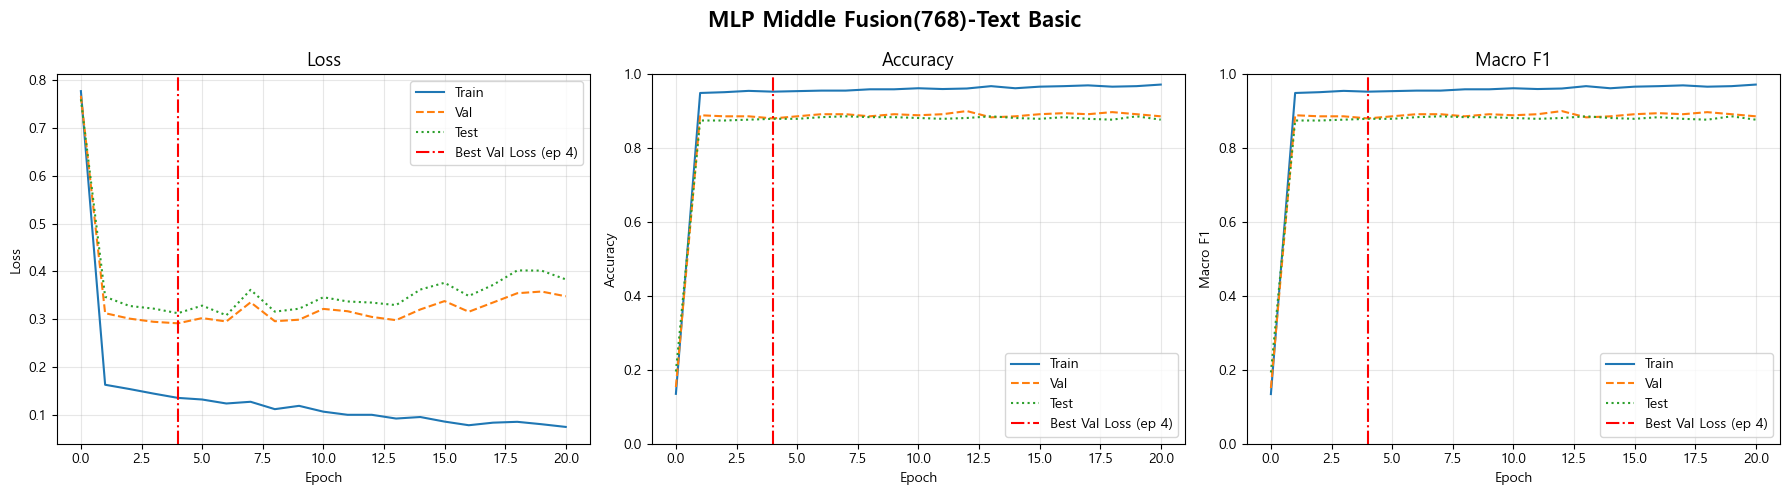

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Learning Curves 시각화
# - 이 노트북은 Early Stopping을 쓰지 않으므로
#   ES stop 대신 Val Loss가 가장 낮았던 epoch을 표시함
# =========================

required_keys = [
    "train_loss", "val_loss", "test_loss",
    "train_acc", "val_acc", "test_acc",
    "train_f1", "val_f1", "test_f1"
]


# history에는 Epoch 0(학습 전 초기 성능)이 들어가 있으므로 x축도 0부터 시작
epochs_range = np.arange(len(history["train_loss"]))

best_val_epoch = int(np.argmin(history["val_loss"]))

plt.figure(figsize=(18, 5))
plt.suptitle("MLP Middle Fusion(768)-Text Basic", fontsize=16, fontweight="bold")

# =========================
# 1. Loss Curve
# =========================
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="Train")
plt.plot(epochs_range, history["val_loss"], linestyle="--", label="Val")
plt.plot(epochs_range, history["test_loss"], linestyle=":", label="Test")
plt.axvline(
    x=best_val_epoch,
    color="red",
    linestyle="-.",
    label=f"Best Val Loss (ep {best_val_epoch})"
)
plt.title("Loss", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

# =========================
# 2. Accuracy Curve
# =========================
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["train_acc"], label="Train")
plt.plot(epochs_range, history["val_acc"], linestyle="--", label="Val")
plt.plot(epochs_range, history["test_acc"], linestyle=":", label="Test")
plt.axvline(
    x=best_val_epoch,
    color="red",
    linestyle="-.",
    label=f"Best Val Loss (ep {best_val_epoch})"
)
plt.title("Accuracy", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()

# =========================
# 3. F1 Score Curve
# =========================
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history["train_f1"], label="Train")
plt.plot(epochs_range, history["val_f1"], linestyle="--", label="Val")
plt.plot(epochs_range, history["test_f1"], linestyle=":", label="Test")
plt.axvline(
    x=best_val_epoch,
    color="red",
    linestyle="-.",
    label=f"Best Val Loss (ep {best_val_epoch})"
)
plt.title("Macro F1", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



## 9. test confusion matrix 시각화

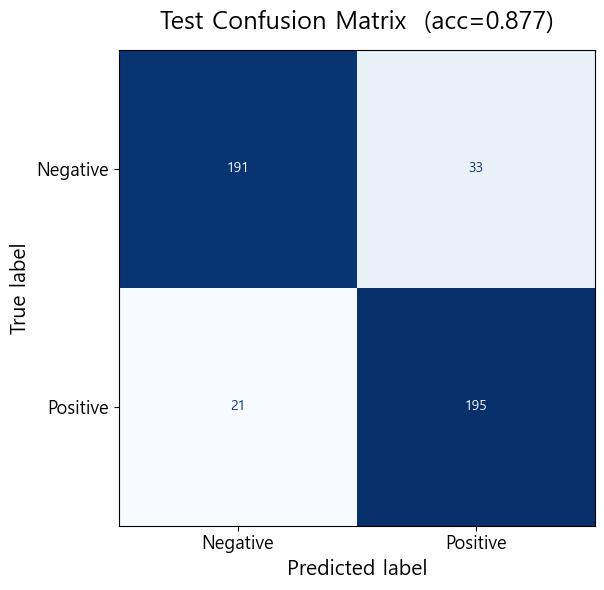

In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay

# =========================
# Test 예측값 수집
# - 이 파일의 모델 변수명은 mlp가 아니라 MLP임
# - 마지막 출력층이 Linear(..., 3)이므로 기본 3-class confusion matrix로 그림
# =========================

MLP.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = MLP(X_batch)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 모델 출력 class 수 자동 확인
try:
    num_classes = MLP[-1].out_features
except Exception:
    num_classes = int(max(all_labels.max(), all_preds.max()) + 1)

labels = list(range(num_classes))

# class 이름 설정: 필요하면 여기만 네 데이터셋 라벨명에 맞게 바꾸면 됨
if num_classes == 2:
    display_labels = ["Negative", "Positive"]

else:
    display_labels = [f"Class {i}" for i in labels]

# =========================
# Confusion Matrix 계산
# =========================
cm = confusion_matrix(all_labels, all_preds, labels=labels)
test_acc = accuracy_score(all_labels, all_preds)

# =========================
# Confusion Matrix 시각화
# =========================
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title(f"Test Confusion Matrix  (acc={test_acc:.3f})", fontsize=18, pad=15)
ax.set_xlabel("Predicted label", fontsize=15)
ax.set_ylabel("True label", fontsize=15)
ax.tick_params(axis="both", labelsize=13)

plt.tight_layout()
plt.show()



## 10. Modlity Ablation Study

In [29]:
feature_sets = {
    "Text only"           : X_text,
    "Audio only"          : X_audio,
    "Video only"          : X_video,
    "Text + Audio"        : torch.cat([X_text, X_audio], dim=1),
    "Text + Video"        : torch.cat([X_text, X_video], dim=1),
    "Audio + Video"       : torch.cat([X_audio, X_video], dim=1),
    "Text + Audio + Video": torch.cat([X_text, X_audio, X_video], dim=1)
}

ablation_results = []

for model_name, feat in feature_sets.items():
    print(f"\n============================== {model_name} ==============================")

    feat_np = feat.cpu().numpy()
    y_np    = y.cpu().numpy()

    # BERT 방식 동일 분할
    Xtr_val, Xte, ytr_val, yte = train_test_split(
        feat_np, y_np, test_size=0.2, random_state=42, stratify=y_np
    )
    Xtr, Xva, ytr, yva = train_test_split(
        Xtr_val, ytr_val, test_size=0.1, random_state=42, stratify=ytr_val
    )

    Xtr = torch.tensor(Xtr, dtype=torch.float32).to(device)
    Xva = torch.tensor(Xva, dtype=torch.float32).to(device)
    Xte = torch.tensor(Xte, dtype=torch.float32).to(device)
    ytr = torch.tensor(ytr, dtype=torch.long).to(device)
    yva = torch.tensor(yva, dtype=torch.long).to(device)
    yte = torch.tensor(yte, dtype=torch.long).to(device)

    abl_train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
    abl_val_loader   = DataLoader(TensorDataset(Xva, yva), batch_size=32, shuffle=False)
    abl_test_loader  = DataLoader(TensorDataset(Xte, yte), batch_size=32, shuffle=False)

    abl_input_dim = Xtr.shape[1]
    mlp_abl = nn.Sequential(
        nn.Linear(abl_input_dim, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 3)
    ).to(device)

    abl_criterion = nn.CrossEntropyLoss()
    abl_optimizer = torch.optim.Adam(mlp_abl.parameters(), lr=0.001)

    for epoch in range(20):
        mlp_abl.train()
        for X_batch, y_batch in abl_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            abl_optimizer.zero_grad()
            loss = abl_criterion(mlp_abl(X_batch), y_batch)
            loss.backward()
            abl_optimizer.step()

    # 최종 평가
    def abl_evaluate(model, loader):
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for Xb, yb in loader:
                Xb, yb = Xb.to(device), yb.to(device)
                _, preds = torch.max(model(Xb), dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())
        return (
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='macro', zero_division=0)
        )

    tr_acc, tr_f1 = abl_evaluate(mlp_abl, abl_train_loader)
    va_acc, va_f1 = abl_evaluate(mlp_abl, abl_val_loader)
    te_acc, te_f1 = abl_evaluate(mlp_abl, abl_test_loader)

    print(f"Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f} | Test Acc: {te_acc:.4f}")
    print(f"Train F1 : {tr_f1:.4f} | Val F1 : {va_f1:.4f} | Test F1 : {te_f1:.4f}")

    ablation_results.append({
        "Modality"  : model_name,
        "Train Acc" : round(tr_acc, 4),
        "Val Acc"   : round(va_acc, 4),
        "Test Acc"  : round(te_acc, 4),
        "Train F1"  : round(tr_f1, 4),
        "Val F1"    : round(va_f1, 4),
        "Test F1"   : round(te_f1, 4),
    })

df_results = pd.DataFrame(ablation_results)
print("\n===================== Ablation Study 결과 =====================")
print(df_results.to_string(index=False))


============================== Text only ==============================
Train Acc: 0.9507 | Val Acc: 0.8182 | Test Acc: 0.8818
Train F1 : 0.9507 | Val F1 : 0.8182 | Test F1 : 0.8818

============================== Audio only ==============================
Train Acc: 0.8023 | Val Acc: 0.7386 | Test Acc: 0.6818
Train F1 : 0.8023 | Val F1 : 0.7386 | Test F1 : 0.6818

============================== Video only ==============================
Train Acc: 0.8080 | Val Acc: 0.5398 | Test Acc: 0.6023
Train F1 : 0.8062 | Val F1 : 0.5331 | Test F1 : 0.5981

============================== Text + Audio ==============================
Train Acc: 0.9583 | Val Acc: 0.8466 | Test Acc: 0.8773
Train F1 : 0.9583 | Val F1 : 0.8466 | Test F1 : 0.8773

============================== Text + Video ==============================
Train Acc: 0.9716 | Val Acc: 0.8125 | Test Acc: 0.8659
Train F1 : 0.9716 | Val F1 : 0.8125 | Test F1 : 0.8659

============================== Audio + Video ==============================


## 11. Ablation Study 시각화

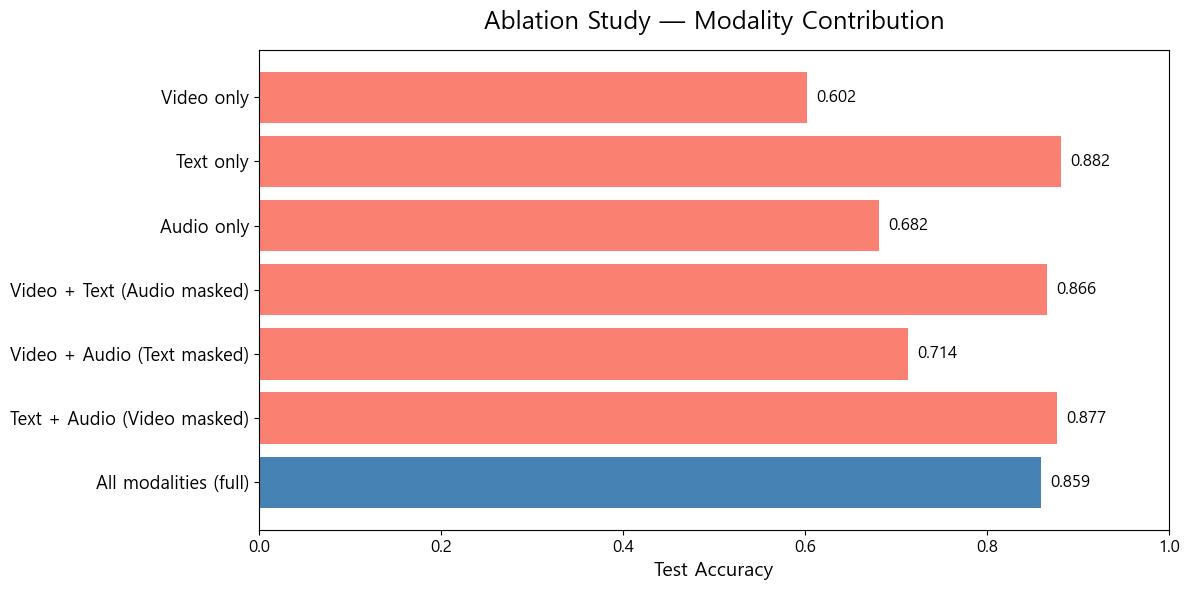

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# df_results 기준 Ablation 결과 정리
# - 이 노트북에서는 results_df가 아니라 df_results라는 이름으로 저장됨
# - df_results는 위 Ablation Study 셀을 먼저 실행해야 생성됨
# =========================

if "df_results" not in globals():
    raise NameError("df_results가 없습니다. 먼저 'Modality Ablation Study' 셀을 실행해 주세요.")

ablation_df = df_results.copy()

# 기존 이름을 사진 스타일 이름으로 변경
name_map = {
    "Video only": "Video only",
    "Text only": "Text only",
    "Audio only": "Audio only",
    "Text + Video": "Video + Text (Audio masked)",
    "Audio + Video": "Video + Audio (Text masked)",
    "Text + Audio": "Text + Audio (Video masked)",
    "Text + Audio + Video": "All modalities (full)"
}

ablation_df["Plot Name"] = ablation_df["Modality"].map(name_map).fillna(ablation_df["Modality"])

# 사진과 같은 순서로 정렬
plot_order = [
    "Video only",
    "Text only",
    "Audio only",
    "Video + Text (Audio masked)",
    "Video + Audio (Text masked)",
    "Text + Audio (Video masked)",
    "All modalities (full)"
]

ablation_df["Plot Name"] = pd.Categorical(
    ablation_df["Plot Name"],
    categories=plot_order,
    ordered=True
)

ablation_df = ablation_df.sort_values("Plot Name")

labels = ablation_df["Plot Name"].tolist()
values = ablation_df["Test Acc"].astype(float).to_numpy()

# 혹시 Test Acc가 0~100 형태로 저장되어 있으면 0~1로 변환
if values.max() > 1.5:
    values = values / 100

# All modalities만 파란색, 나머지는 살몬색
colors = [
    "steelblue" if label == "All modalities (full)" else "salmon"
    for label in labels
]

# =========================
# Ablation Study 시각화
# =========================
plt.figure(figsize=(12, 6))

bars = plt.barh(labels, values, color=colors)

plt.title("Ablation Study — Modality Contribution", fontsize=18, pad=15)
plt.xlabel("Test Accuracy", fontsize=14)
plt.xlim(0, 1.0)

plt.xticks(fontsize=12)
plt.yticks(fontsize=13)

# 막대 오른쪽에 수치 표시
for bar, value in zip(bars, values):
    plt.text(
        min(value + 0.01, 0.98),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=12
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



C:\Users\User\AppData\Local\Temp\ipykernel_11036\3438089426.py:72: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_11036\3438089426.py:75: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig("feature_distribution_pca.png", dpi=300, bbox_inches="tight")
c:\Users\User\AppData\Local\anaconda3\envs\main\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


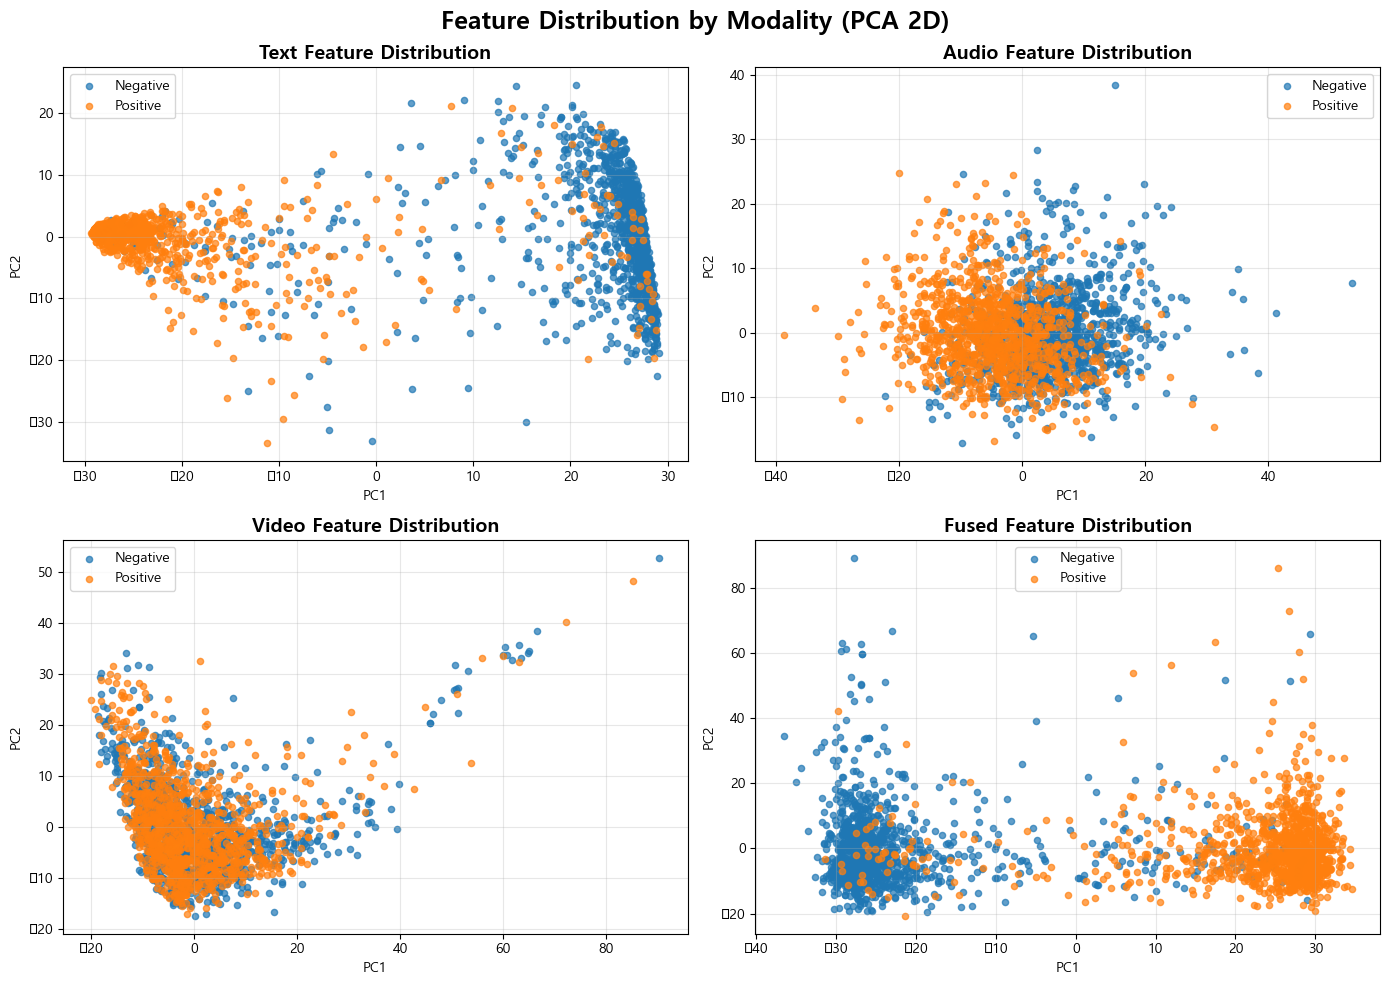

In [31]:
# =========================
# Feature 분포 시각화
# - Text / Audio / Video / Fused feature를 PCA 2D로 시각화
# =========================

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# Tensor -> numpy 변환 함수
# =========================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)

# =========================
# 시각화할 feature 모음
# =========================
feature_viz_sets = {
    "Text Feature": X_text,
    "Audio Feature": X_audio,
    "Video Feature": X_video,
    "Fused Feature": fused
}

labels_np = to_numpy(y).astype(int)

# 라벨 이름 설정
label_name_map = {
    0: "Negative",
    1: "Positive"
}

# =========================
# PCA 기반 Feature 분포 시각화
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (feature_name, feature_data) in zip(axes, feature_viz_sets.items()):
    feature_np = to_numpy(feature_data)

    # feature scale 차이를 줄이기 위해 표준화
    feature_scaled = StandardScaler().fit_transform(feature_np)

    # PCA로 2차원 축소
    pca = PCA(n_components=2, random_state=42)
    feature_pca = pca.fit_transform(feature_scaled)

    # 라벨별 scatter plot
    for label in np.unique(labels_np):
        idx = labels_np == label
        ax.scatter(
            feature_pca[idx, 0],
            feature_pca[idx, 1],
            s=20,
            alpha=0.7,
            label=label_name_map.get(label, f"Class {label}")
        )

    ax.set_title(f"{feature_name} Distribution", fontsize=14, fontweight="bold")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Feature Distribution by Modality (PCA 2D)", fontsize=18, fontweight="bold")
plt.tight_layout()

# 이미지 저장
plt.savefig("feature_distribution_pca.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
# 한글 폰트 설정
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import platform

if platform.system() == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"   
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams["font.family"] = font_name

            

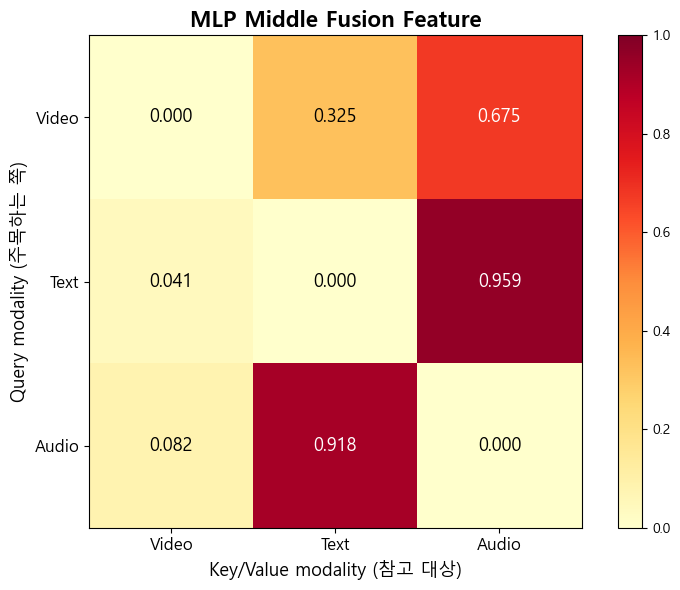

In [33]:
# =========================
# Modality Feature Relation Heatmap
# - Video / Text / Audio feature 간 관계 시각화
# - CKA similarity 기반
# =========================

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# =========================
# Tensor -> numpy 변환 함수
# =========================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)

# =========================
# CKA Similarity 계산 함수
# - feature 차원이 달라도 비교 가능
# =========================
def linear_cka(X, Y):
    X = StandardScaler().fit_transform(X)
    Y = StandardScaler().fit_transform(Y)

    K = X @ X.T
    L = Y @ Y.T

    hsic = np.sum(K * L)
    norm_x = np.sqrt(np.sum(K * K))
    norm_y = np.sqrt(np.sum(L * L))

    return hsic / (norm_x * norm_y + 1e-8)

# =========================
# Feature 준비
# =========================
modalities = ["Video", "Text", "Audio"]

features = {
    "Video": to_numpy(X_video),
    "Text": to_numpy(X_text),
    "Audio": to_numpy(X_audio)
}

# =========================
# 모달리티 간 유사도 행렬 계산
# =========================
similarity_matrix = np.zeros((len(modalities), len(modalities)))

for i, q_mod in enumerate(modalities):
    for j, kv_mod in enumerate(modalities):
        if i == j:
            similarity_matrix[i, j] = 0.0
        else:
            similarity_matrix[i, j] = linear_cka(features[q_mod], features[kv_mod])

# =========================
# 행 기준 정규화
# - 예시 이미지처럼 한 모달리티가 다른 모달리티를 참조하는 비율로 표현
# =========================
relation_matrix = similarity_matrix.copy()

for i in range(relation_matrix.shape[0]):
    row_sum = relation_matrix[i].sum()
    if row_sum > 0:
        relation_matrix[i] = relation_matrix[i] / row_sum

# =========================
# Heatmap 시각화
# =========================
plt.figure(figsize=(8, 6))

im = plt.imshow(relation_matrix, cmap="YlOrRd", vmin=0, vmax=1)

plt.xticks(range(len(modalities)), modalities, fontsize=12)
plt.yticks(range(len(modalities)), modalities, fontsize=12)

plt.xlabel("Key/Value modality (참고 대상)", fontsize=13)
plt.ylabel("Query modality (주목하는 쪽)", fontsize=13)
plt.title("MLP Middle Fusion Feature", fontsize=16, fontweight="bold")

# 값 표시
for i in range(len(modalities)):
    for j in range(len(modalities)):
        value = relation_matrix[i, j]
        text_color = "white" if value > 0.4 else "black"
        plt.text(
            j, i,
            f"{value:.3f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=13
        )

plt.colorbar(im)
plt.tight_layout()

# 이미지 저장
plt.savefig("modality_feature_relation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()